In [3]:
import yfinance as yf
import pandas as pd

tickers=['AAPL','BTC-USD','^GSPC','GC=F','CL=F']
start="2021-01-01"
end="2026-03-25"
data={}
for ticker in tickers:
    data[ticker]=yf.download(ticker,start=start,end=end)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [ ]:
data

In [5]:
prices = pd.DataFrame({
    ticker: data[ticker]["Close"].squeeze()
    for ticker in tickers
})

In [6]:
prices.head()

,AAPL,BTC-USD,^GSPC,GC=F,CL=F
Date,,,,,
2021-01-01,NaN,29374.152344,NaN,NaN,NaN
2021-01-02,NaN,32127.267578,NaN,NaN,NaN
2021-01-03,NaN,32782.023438,NaN,NaN,NaN
2021-01-04,125.856705,31971.914062,3700.649902,1944.699951,47.619999
2021-01-05,127.412773,33992.429688,3726.860107,1952.699951,49.930000


In [7]:
prices = prices.dropna()
print(prices.shape)

(1311, 5)


In [8]:
# Rendements simples
returns_simple = prices.pct_change()

# Rendements logarithmiques
import numpy as np
returns_log = np.log(prices / prices.shift(1))

In [9]:
prices.head()

,AAPL,BTC-USD,^GSPC,GC=F,CL=F
Date,,,,,
2021-01-04,125.856705,31971.914062,3700.649902,1944.699951,47.619999
2021-01-05,127.412773,33992.429688,3726.860107,1952.699951,49.930000
2021-01-06,123.123840,36824.363281,3748.139893,1906.900024,50.630001
2021-01-07,127.325249,39371.042969,3803.790039,1912.300049,50.830002
2021-01-08,128.424194,40797.609375,3824.679932,1834.099976,52.240002


In [10]:
print(returns_log.head())

                AAPL   BTC-USD     ^GSPC      GC=F      CL=F
Date                                                        
2021-01-04       NaN       NaN       NaN       NaN       NaN
2021-01-05  0.012288  0.061280  0.007058  0.004105  0.047369
2021-01-06 -0.034241  0.080022  0.005694 -0.023734  0.013922
2021-01-07  0.033554  0.066871  0.014738  0.002828  0.003942
2021-01-08  0.008594  0.035593  0.005477 -0.041753  0.027362


In [11]:
returns_log = returns_log.dropna()

In [12]:
volatilite_journaliere = returns_log.std()
print(volatilite_journaliere.sort_values(ascending=False))

BTC-USD    0.037119
CL=F       0.023899
AAPL       0.017420
GC=F       0.011275
^GSPC      0.010573
dtype: float64


In [13]:
volatilite_annuelle = returns_log.std() * (252 ** 0.5)
print(volatilite_annuelle.sort_values(ascending=False))

BTC-USD    0.589252
CL=F       0.379384
AAPL       0.276532
GC=F       0.178983
^GSPC      0.167848
dtype: float64


In [16]:
rendement_annuel = returns_log.mean() * 252
print(rendement_annuel.sort_values(ascending=False))

GC=F       0.157036
BTC-USD    0.152163
AAPL       0.133282
CL=F       0.127411
^GSPC      0.110020
dtype: float64


In [17]:
rf = 0.04  # taux sans risque 4%

sharpe = (rendement_annuel - rf) / volatilite_annuelle
print(sharpe.sort_values(ascending=False))

GC=F       0.653894
^GSPC      0.417163
AAPL       0.337329
CL=F       0.230402
BTC-USD    0.190349
dtype: float64


In [18]:
correlation = returns_log.corr()
print(correlation)

             AAPL   BTC-USD     ^GSPC      GC=F      CL=F
AAPL     1.000000  0.243566  0.749733  0.019486  0.048191
BTC-USD  0.243566  1.000000  0.379401  0.047195  0.029409
^GSPC    0.749733  0.379401  1.000000  0.069924  0.123600
GC=F     0.019486  0.047195  0.069924  1.000000  0.146031
CL=F     0.048191  0.029409  0.123600  0.146031  1.000000


In [25]:
# Période de crise : invasion Ukraine + hausse des taux
crise = returns_log["2026-01-01":"2026-03-30"]
print(crise.corr())

             AAPL   BTC-USD     ^GSPC      GC=F      CL=F
AAPL     1.000000  0.024280  0.515990 -0.077111 -0.206362
BTC-USD  0.024280  1.000000  0.564436  0.075344 -0.025334
^GSPC    0.515990  0.564436  1.000000  0.103152 -0.301121
GC=F    -0.077111  0.075344  0.103152  1.000000  0.112896
CL=F    -0.206362 -0.025334 -0.301121  0.112896  1.000000


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
normalized = (prices / prices.iloc[0]) * 100

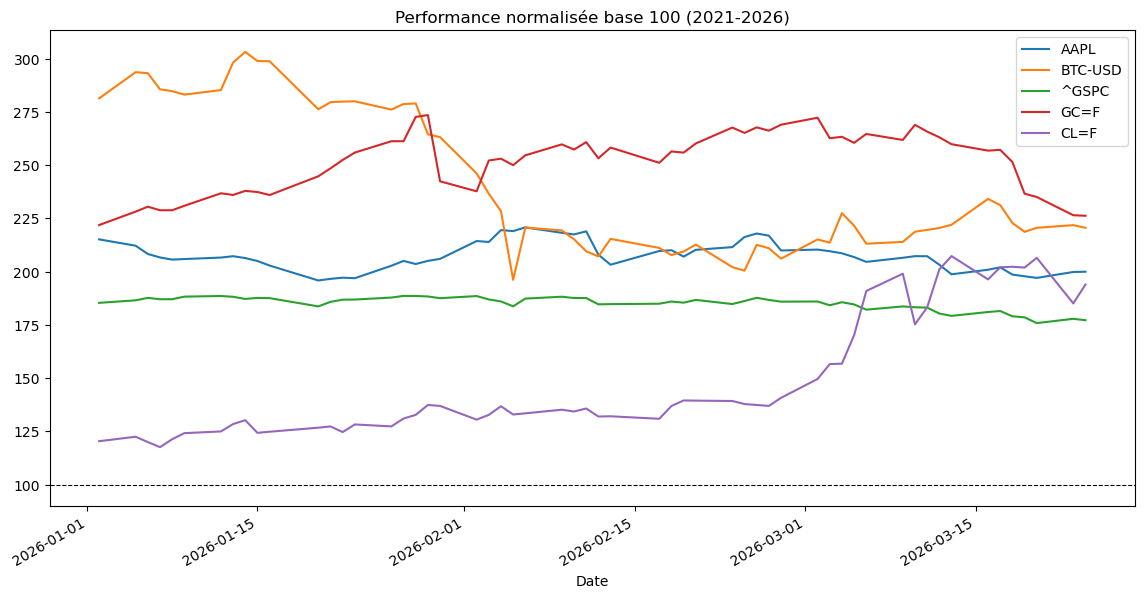

In [30]:
normalized["2026-01-01":"2026-03-30"].plot(figsize=(14, 7), title="Performance normalisée base 100 (2021-2026)")
plt.axhline(y=100, color='black', linestyle='--', linewidth=0.8)
plt.legend()
plt.show()

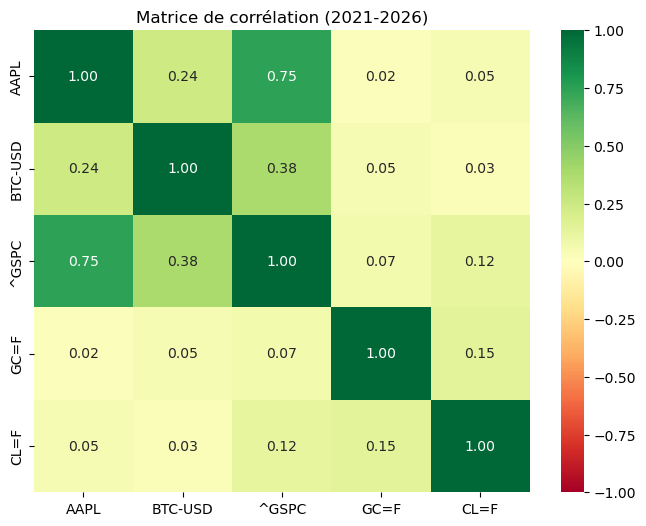

In [32]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    vmin=-1,
    vmax=1
)
plt.title("Matrice de corrélation (2021-2026)")
plt.show()

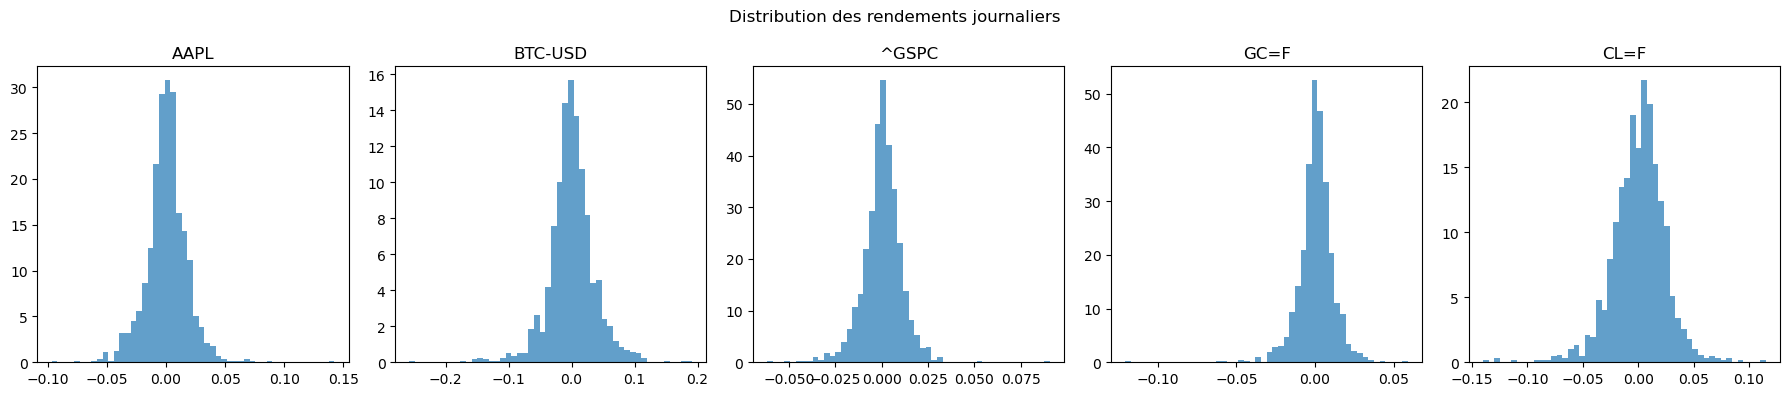

In [33]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, ticker in enumerate(tickers):
    axes[i].hist(returns_log[ticker], bins=50, density=True, alpha=0.7)
    axes[i].set_title(ticker)
    
plt.suptitle("Distribution des rendements journaliers")
plt.tight_layout()
plt.show()

In [36]:
periodes = {
    "2021": ("2021-01-01", "2021-12-31"),
    "2022": ("2022-01-01", "2022-12-31"),
    "2024-2026": ("2024-01-01", "2026-03-25"),
    "la guerre":("2026-01-01", "2026-03-25")
}

for periode, (debut, fin) in periodes.items():
    print(f"\n=== {periode} ===")
    rendement = returns_log[debut:fin].mean() * 252
    print(rendement.sort_values(ascending=False).round(3))


=== 2021 ===
CL=F       0.459
BTC-USD    0.372
AAPL       0.324
^GSPC      0.254
GC=F      -0.062
dtype: float64

=== 2022 ===
CL=F       0.065
GC=F      -0.004
^GSPC     -0.217
AAPL      -0.308
BTC-USD   -1.030
dtype: float64

=== 2024-2026 ===
GC=F       0.342
BTC-USD    0.233
^GSPC      0.144
AAPL       0.126
CL=F       0.115
dtype: float64

=== la guerre ===
CL=F       2.138
GC=F       0.076
^GSPC     -0.194
AAPL      -0.344
BTC-USD   -0.971
dtype: float64


In [37]:
# Portefeuille 50% Or / 50% S&P500
poids = {"GC=F": 0.5, "^GSPC": 0.5}

rendement_portefeuille = sum(
    poids[t] * rendement_annuel[t] 
    for t in poids
)

volatilite_portefeuille = sum(
    poids[t] * volatilite_annuelle[t] 
    for t in poids
)

sharpe_portefeuille = (rendement_portefeuille - 0.04) / volatilite_portefeuille

print(f"Rendement annuel : {rendement_portefeuille:.1%}")
print(f"Volatilité : {volatilite_portefeuille:.1%}")
print(f"Ratio de Sharpe : {sharpe_portefeuille:.2f}")

Rendement annuel : 13.4%
Volatilité : 17.3%
Ratio de Sharpe : 0.54


In [38]:
rendement_annuel

AAPL       0.133282
BTC-USD    0.152163
^GSPC      0.110020
GC=F       0.157036
CL=F       0.127411
dtype: float64